# does log(log(death/birth)) track the point process params?

sing the Matern hard-core diagrams (already
computed, 7000 of them, `parent_intensity` and `hardcore_radius` swept on a log
grid) since it's a clean 2-parameter case and no recomputation is needed.

Per diagram I take the max and the median of log(log(death/birth)) over finite
H0/H1 pairs, and correlate each against log(param).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cloudforger.core.records import load_diagrams

OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
diagrams, _bundle = load_diagrams(ROOT / "data" / "matern" / "dtm_k10" / "diagrams.pkl")
print(f"{len(diagrams)} diagrams available")

N_SAMPLE = 600
rng = np.random.default_rng(0)
sample = [diagrams[i] for i in rng.choice(len(diagrams), size=N_SAMPLE, replace=False)]

7000 diagrams available


In [3]:
rows = []
for d in sample:
    for dim in (0, 1):
        pairs = d.finite_pairs(dim)  # drops the one infinite-death H0 class
        if len(pairs) == 0:
            continue
        ratio = pairs[:, 1] / pairs[:, 0]
        loglog = np.log(np.log(ratio))  # ratio > 1 always, so log(ratio) > 0
        rows.append(dict(
            dim=dim,
            parent_intensity=d.generator_params["parent_intensity"],
            hardcore_radius=d.generator_params["hardcore_radius"],
            median_loglog=np.median(loglog),
            max_loglog=np.max(loglog),
        ))

def col(name):
    return np.array([r[name] for r in rows])

dim_arr = col("dim")
print(f"{len(rows)} (diagram, dim) rows")

1200 (diagram, dim) rows


In [4]:
print(f"{'dim':>3} {'stat':>13} {'param':>16} {'pearson r (log param)':>22}")
for dim in (0, 1):
    mask = dim_arr == dim
    for stat in ("max_loglog", "median_loglog"):
        y = col(stat)[mask]
        for param in ("parent_intensity", "hardcore_radius"):
            x = np.log(col(param)[mask])
            r, _p = pearsonr(x, y)
            print(f"{dim:>3} {stat:>13} {param:>16} {r:>22.3f}")

dim          stat            param  pearson r (log param)
  0    max_loglog parent_intensity                 -0.081
  0    max_loglog  hardcore_radius                 -0.683
  0 median_loglog parent_intensity                  0.783
  0 median_loglog  hardcore_radius                  0.519
  1    max_loglog parent_intensity                  0.569
  1    max_loglog  hardcore_radius                 -0.182
  1 median_loglog parent_intensity                  0.250
  1 median_loglog  hardcore_radius                 -0.004


## Figure 1 -- max log(log(death/birth)) per diagram

The most prominent feature in each diagram, against each param (log-scaled x-axis,
matching the sweep).

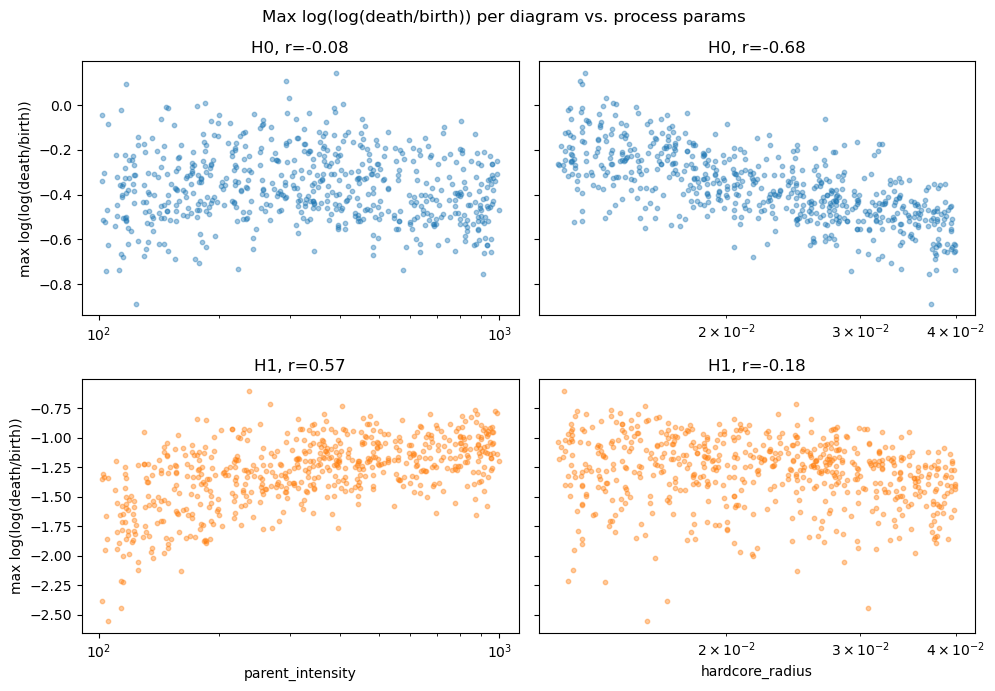

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey="row")
colors = {0: "tab:blue", 1: "tab:orange"}
params = ["parent_intensity", "hardcore_radius"]

for row, dim in enumerate((0, 1)):
    mask = dim_arr == dim
    y = col("max_loglog")[mask]
    for c, param in enumerate(params):
        ax = axes[row, c]
        x = col(param)[mask]
        r, _p = pearsonr(np.log(x), y)
        ax.scatter(x, y, s=10, alpha=0.4, color=colors[dim])
        ax.set_xscale("log")
        ax.set_title(f"H{dim}, r={r:.2f}")
        if row == 1:
            ax.set_xlabel(param)
        if c == 0:
            ax.set_ylabel("max log(log(death/birth))")

fig.suptitle("Max log(log(death/birth)) per diagram vs. process params")
fig.tight_layout()
fig.savefig(OUT / "09_loglog_ratio_max_vs_params.png", dpi=150)
plt.show()

## Figure 2 -- median log(log(death/birth)) per diagram

Bulk behavior instead of just the top feature (dominated by the many short/noisy bars).

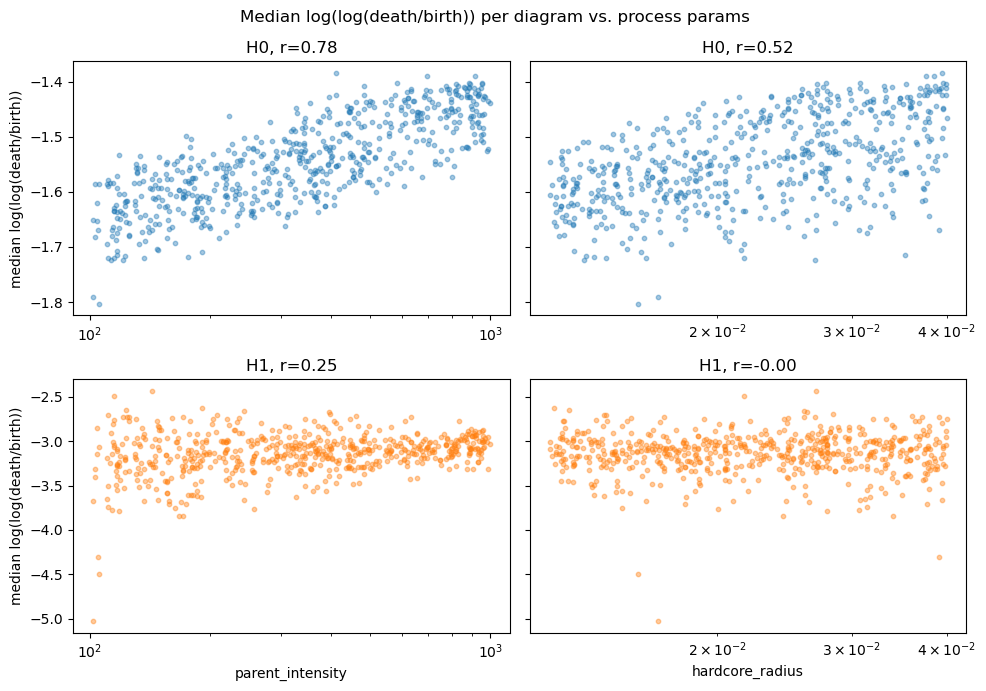

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey="row")

for row, dim in enumerate((0, 1)):
    mask = dim_arr == dim
    y = col("median_loglog")[mask]
    for c, param in enumerate(params):
        ax = axes[row, c]
        x = col(param)[mask]
        r, _p = pearsonr(np.log(x), y)
        ax.scatter(x, y, s=10, alpha=0.4, color=colors[dim])
        ax.set_xscale("log")
        ax.set_title(f"H{dim}, r={r:.2f}")
        if row == 1:
            ax.set_xlabel(param)
        if c == 0:
            ax.set_ylabel("median log(log(death/birth))")

fig.suptitle("Median log(log(death/birth)) per diagram vs. process params")
fig.tight_layout()
fig.savefig(OUT / "10_loglog_ratio_median_vs_params.png", dpi=150)
plt.show()